In [1]:
from mosqlient import get_infodengue

api_key = "eduardocorrearaujo:00566e8d-b64b-44a3-83b7-b50a086096e0"

In [2]:
import numpy as np
import pandas as pd 
from epiweeks import Week
import matplotlib.pyplot as plt

In [3]:
state = 'RJ'
begin_date = '2025-01-01'

In [4]:
df_info = get_infodengue(api_key = api_key, uf = state, start_date = begin_date,
                        disease = 'dengue', end_date = '2025-06-05')

df_info.head()

100%|███████████████████████████████████████| 6/6 [00:02<00:00,  2.38requests/s]


,data_iniSE,SE,casos_est,casos_est_min,casos_est_max,casos,municipio_geocodigo,p_rt1,p_inc100k,Localidade_id,...,nivel_inc,umidmed,umidmin,tempmed,tempmax,casprov,casprov_est,casprov_est_min,casprov_est_max,casconf
0,2025-05-25,202522,0.0,0,0.0,0,3303807,0.000000,0.000000,0,...,0,79.767775,62.621675,20.063325,23.66810,0,None,None,None,None
1,2025-05-25,202522,40.0,4,235.0,0,3300506,0.539273,142.015200,0,...,2,82.757175,61.624275,18.138200,22.15295,0,None,None,None,None
2,2025-05-25,202522,20.0,5,51.0,0,3302403,0.378622,7.613479,0,...,1,83.236200,63.575950,20.861250,24.62880,0,None,None,None,None
3,2025-05-25,202522,17.0,3,91.0,1,3301207,0.000003,99.131140,0,...,2,78.347475,56.277675,19.779050,24.20255,1,None,None,None,None
4,2025-05-25,202522,0.0,0,5.0,0,3301108,0.000000,0.000000,0,...,0,75.944500,52.978150,20.615775,25.04660,0,None,None,None,None


In [5]:
df_info.data_iniSE = pd.to_datetime(df_info.data_iniSE)
df_info = df_info.groupby('data_iniSE')[['casprov']].sum()
df_info.head()

,casprov
data_iniSE,
2025-01-05,720
2025-01-12,762
2025-01-19,955
2025-01-26,1256
2025-02-02,1857


In [6]:
df_ref = pd.read_csv('/Users/eduardoaraujo/Documents/sprint_data_2025/dengue.csv.gz')
df_ref = df_ref.loc[df_ref.uf == state]
df_ref.date = pd.to_datetime(df_ref.date)
df_ref = df_ref.loc[df_ref.date >= begin_date].set_index('date')
df_ref = df_ref.groupby('date')[['casos']].sum()
df_ref.head()

,casos
date,
2025-01-05,720
2025-01-12,762
2025-01-19,955
2025-01-26,1256
2025-02-02,1832


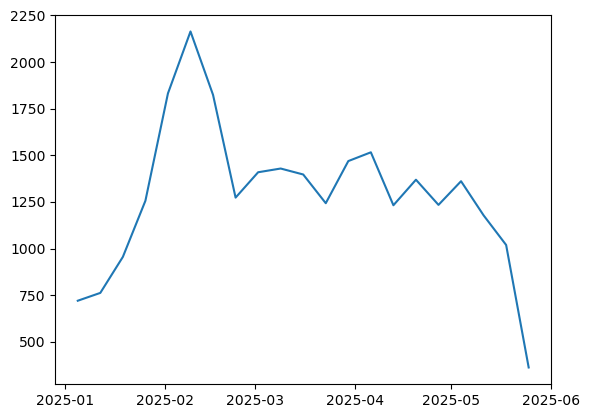

In [7]:
_,ax = plt.subplots()

ax.plot(df_ref.casos)

In [8]:
df = pd.read_csv(f'/Users/eduardoaraujo/Documents/Github/load_infodengue_data/dengue_{state}_25.csv.gz')
df.head()

,Unnamed: 0,dt_notific,dt_sin_pri,se_sin_pri,municipio_geocodigo,dt_digita,cid10_codigo,criterio,classi_fin
0,0,2024-12-30,2024-12-29,1,3303807,2025-01-29,A90,2.0,5.0
1,1,2025-01-27,2025-01-25,4,3303906,2025-02-04,A90,2.0,5.0
2,2,2025-01-27,2025-01-26,5,3304201,2025-02-06,A90,2.0,5.0
3,3,2025-02-11,2025-01-16,3,3306156,2025-02-14,A90,1.0,5.0
4,4,2025-03-13,2025-03-09,11,3301702,2025-04-03,A90,2.0,10.0


In [11]:
df_ = df.loc[(df.classi_fin != 5)]

df_['dt_sin_pri'] = pd.to_datetime(df_['dt_sin_pri'])

df_ = df_.loc[df_['dt_sin_pri'] >= begin_date]

df_['epiweek'] = df_.apply(lambda row: Week.fromdate(row['dt_sin_pri']).startdate(), axis=1)

df_.head()

/var/folders/ch/kxpr39wx44v97968yr_4hmch0000gn/T/ipykernel_16046/3669232163.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_['dt_sin_pri'] = pd.to_datetime(df_['dt_sin_pri'])


,Unnamed: 0,dt_notific,dt_sin_pri,se_sin_pri,municipio_geocodigo,dt_digita,cid10_codigo,criterio,classi_fin,epiweek
4,4,2025-03-13,2025-03-09,11,3301702,2025-04-03,A90,2.0,10.0,2025-03-09
5,5,2025-03-19,2025-03-16,12,3304557,2025-03-19,A90,3.0,11.0,2025-03-16
6,6,2025-03-28,2025-03-26,13,3304557,2025-04-01,A90,0.0,0.0,2025-03-23
9,9,2025-04-01,2025-03-24,13,3302502,2025-04-04,A90,3.0,10.0,2025-03-23
10,10,2025-04-01,2025-03-27,13,3302502,2025-04-04,A90,3.0,10.0,2025-03-23


In [12]:
df_.isnull().sum()

Unnamed: 0             0
dt_notific             0
dt_sin_pri             0
se_sin_pri             0
municipio_geocodigo    0
dt_digita              0
cid10_codigo           0
criterio               0
classi_fin             0
epiweek                0
dtype: int64

In [13]:
df_banco = df_[['epiweek', 'se_sin_pri']].groupby('epiweek').count()
df_banco.head()

,se_sin_pri
epiweek,
2024-12-29,384
2025-01-05,720
2025-01-12,762
2025-01-19,955
2025-01-26,1256


[]

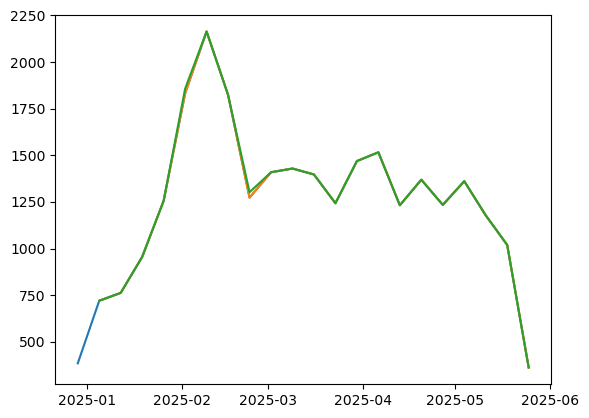

In [14]:
_,ax = plt.subplots()

ax.plot(df_banco.se_sin_pri)
ax.plot(df_ref.casos)
ax.plot(df_info.casprov)

ax.plot()